here i am importing libraries just pandas for slicing and numpy for easy math operations , matplotlib for graphs and charts and re for text cleaning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

here i am loading dataset and then printing it


In [2]:
df = pd.read_csv("Resume.csv")
print(df)

            ID                                         Resume_str  \
0     16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1     22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2     33176873           HR DIRECTOR       Summary      Over 2...   
3     27018550           HR SPECIALIST       Summary    Dedica...   
4     17812897           HR MANAGER         Skill Highlights  ...   
...        ...                                                ...   
2479  99416532           RANK: SGT/E-5 NON- COMMISSIONED OFFIC...   
2480  24589765           GOVERNMENT RELATIONS, COMMUNICATIONS ...   
2481  31605080           GEEK SQUAD AGENT         Professional...   
2482  21190805           PROGRAM DIRECTOR / OFFICE MANAGER    ...   
2483  37473139           STOREKEEPER II       Professional Sum...   

                                            Resume_html  Category  
0     <div class="fontsize fontface vmargins hmargin...        HR  
1     <div class="fontsize fontface

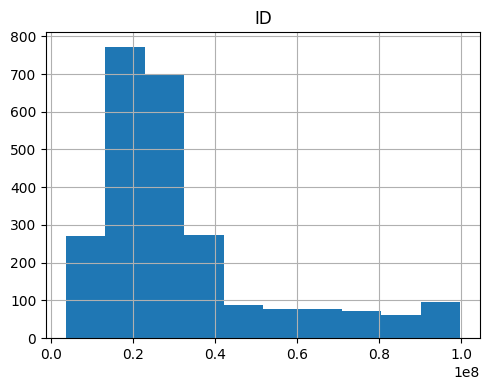

In [3]:
df.hist(figsize=(5, 4))
plt.tight_layout()

In [4]:
df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


just to chk infoo

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


UNDERSTAND DATA:
See column names
Check class distribution
Check missing values

In [7]:
print(df.columns)
print(df['Category'].value_counts())
print(df.isnull().sum())

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


i use this code just to clean the text change it into lower case and remove unwanted data

In [8]:

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"[^a-zA-Z ]", "", text)  # remove special chars
    text = re.sub(r"\s+", " ", text)  # remove extra spaces
    return text

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

print(df[['Resume_str', 'cleaned_resume']].head())

                                          Resume_str  \
0           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1           HR SPECIALIST, US HR OPERATIONS      ...   
2           HR DIRECTOR       Summary      Over 2...   
3           HR SPECIALIST       Summary    Dedica...   
4           HR MANAGER         Skill Highlights  ...   

                                      cleaned_resume  
0   hr administratormarketing associatehr adminis...  
1   hr specialist us hr operations summary versat...  
2   hr director summary over years experience in ...  
3   hr specialist summary dedicated driven and dy...  
4   hr manager skill highlights hr skills hr depa...  


here i change the names of colums to short for easy understanding

In [9]:
df = df.rename(columns={
    'Resume_str': 'resume',
    'Category': 'label'
})

mein ne yahan label encoding kiya hai taki machine learning model ke liye labels ko numerical format me convert kar saku. Iske baad maine TF-IDF vectorization ka use karke cleaned resume text ko numerical features me convert kiya hai.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['label'])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_resume'],
    df['Category_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['Category_encoded']
)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_tfidf, y_train)

LinearSVC()

In [16]:
y_pred = model.predict(X_test_tfidf)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7082494969818913
              precision    recall  f1-score   support

           0       0.72      0.88      0.79        24
           1       0.58      0.75      0.65        24
           2       1.00      0.62      0.76        13
           3       0.44      0.21      0.29        19
           4       0.60      0.43      0.50        21
           5       1.00      0.43      0.60         7
           6       0.86      0.75      0.80        24
           7       0.77      0.74      0.76        23
           8       0.00      0.00      0.00         4
           9       0.53      0.75      0.62        24
          10       0.83      0.79      0.81        24
          11       0.79      0.86      0.83        22
          12       0.70      0.30      0.42        23
          13       0.89      0.81      0.85        21
          14       0.71      0.53      0.61        19
          15       0.72      0.75      0.73        24
          16       0.83      0.79      0.81        2